# AUS2200 xarray rolling mean

## Aim

This recipe shows how to:
- Load a month of AUS2200 data (entire spatial domain) with xarray (dask-enabled) and chunk the data for efficient computing
- Calculate air temperature perturbations to the daily mean (using xarray rolling mean)

## First load some python modules

Requires access to the xp65 conda environment

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import dask.array as da
import dask
from dask.distributed import Client
from dask import delayed

## Compute size
We are working with XX-Large resources on ARE (28 cores, 126 GB)

In [2]:
#Set up a dask distributed client, so that chunks of data can be sent and 
# processed by different cores/"workers".

# Click "Launch dashboard in JupyterLab" within this cell's output to see dask progress

client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 48
Total threads: 48,Total memory: 188.56 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41027,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45885,Total threads: 1
Dashboard: /proxy/35291/status,Memory: 3.93 GiB
Nanny: tcp://127.0.0.1:45283,


## Load in the AUS2200 data

We use intake to do this: check out https://access-nri.github.io/interactive-data-catalogue/#/ to explore available data

In [3]:
import intake
catalog = intake.cat.access_nri

esm_datastore = catalog['AUS2200']

esm_datastore = esm_datastore.search(variable_id='ta', experiment_id='mjo-elnino2016', frequency='1hr') 
esm_datastore

/jobfs/168355648.gadi-pbs/ipykernel_652508/2851339479.py:6: UserWarning: Value aliasing: variable_id='ta' → variable_id=['('fld_s30i204',)','ta']
  esm_datastore = esm_datastore.search(variable_id='ta', experiment_id='mjo-elnino2016', frequency='1hr')


,unique
path,244
file_type,1
realm,1
model_id,1
experiment_id,1
frequency,1
variable_id,1
version,1
time_range,244
derived_variable_id,0


In [4]:
#Define lat lon slices, equivalent to almost the entire AUS2200 domain
lon_slice = slice(108, 159)
lat_slice = slice(-45.7, -6.831799)  

# Single model level (111.7 m)
lev_slice = slice(100, 120)

#Define times to slice
start_time="2016-01-01 00:00"
end_time="2016-02-01 00:00"

In [6]:
aus2200_ta = esm_datastore.to_dask().sel(
    time = slice(start_time, end_time)
).sel(
    lon=lon_slice, lat=lat_slice, lev = lev_slice
).ta

In [7]:
aus2200_ta

<xarray.DataArray 'ta' (time: 744, lev: 1, lat: 1963, lon: 2575)> Size: 15GB
dask.array<getitem, shape=(744, 1, 1963, 2575), dtype=float32, chunksize=(1, 1, 424, 520), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 6kB 2016-01-01T01:00:00 ... 2016-02-01
  * lev      (lev) float64 8B 111.7
  * lat      (lat) float64 16kB -45.7 -45.68 -45.66 ... -6.891 -6.871 -6.852
  * lon      (lon) float64 21kB 108.0 108.0 108.1 108.1 ... 158.9 159.0 159.0
Attributes:
    standard_name:          air_temperature
    long_name:              Air Temperature
    comment:                Air Temperature
    units:                  K
    cell_methods:           area: mean time: point
    cell_measures:          area: areacella
    coverage_content_type:  modelResult

# Chunks

## Advanced (but necessary) topic

Previous versions of this notebook we specified the chunks as `{"time":6,"lat":-1,"lon":-1,"lev":{}}`. For lat and lon, `"-1"` means that the chunk sizes in those dimensions (1963 for lat, 2574 for lon) are equivalent to the length of the dimensions. In other words, the dataset is not chunked up in those dimensions.

However, the dataset is chunked along time (with a chunk size of 6). This is the best we can do for AUS2200 as each file is 6 time steps long. We can rechunk the time dimension later by calling `aus2200_ta.chunk({"time":chunksize})`, but this can be very slow.

Our aim is to have small enough chunks to fit on memory, but large enough chunks to reduce the time taken to pass data between workers and to reduce the number of operations dask is doing. The chunk size here (115 MB) is okay, with around 200 MB being a pretty good aim (although there is no standard rules around what chunk sizes are optimal, it takes some experimenting)

## TLDR;

Advances in the xarray/dask ecosystem means that you can now typically just specify `chunks="auto"` to have dask figure out (close to) optimal chunks for you. Intake takes care of this for us.

## Rolling daily mean

Now we'd like to compute a rolling daily average temperature. Rolling operations can be very slow, because for each point we need to access neighbouring time chunks 

In [40]:
time_window = 24      #equivalent to one day for the hourly data here
min_periods = 12      #for each time step, there must be at least 12 hours in the moving window
                      # for the rolling mean to be defined.
aus2200_ta_daily_mean = aus2200_ta.rolling(
    dim={"time":24},center=True,min_periods=12
).mean()

In [41]:
aus2200_ta_daily_mean

<xarray.DataArray 'ta' (time: 744, lev: 1, lat: 1963, lon: 2575)> Size: 15GB
dask.array<getitem, shape=(744, 1, 1963, 2575), dtype=float32, chunksize=(42, 1, 424, 520), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 6kB 2016-01-01T01:00:00 ... 2016-02-01
  * lev      (lev) float64 8B 111.7
  * lat      (lat) float64 16kB -45.7 -45.68 -45.66 ... -6.891 -6.871 -6.852
  * lon      (lon) float64 21kB 108.0 108.0 108.1 108.1 ... 158.9 159.0 159.0
Attributes:
    standard_name:          air_temperature
    long_name:              Air Temperature
    comment:                Air Temperature
    units:                  K
    cell_methods:           area: mean time: point
    cell_measures:          area: areacella
    coverage_content_type:  modelResult

## Computing

Note that dask hasn't done anything yet because we haven't actually needed to access any data (with only metadata shown above so far). When we start making plots in the following cells, then dask will actually start doing computations and loading the required data into memory.

If for some reason we would like all the data in memory to access it, we can use compute() or persist() commands, such as 

`aus2200_ta_daily_mean = aus2200_ta_daily_mean.persist()`

## Plotting

Lets plot a single time step and start some computations. Note that the daily mean here smooths out small variations compared with the original temperature field

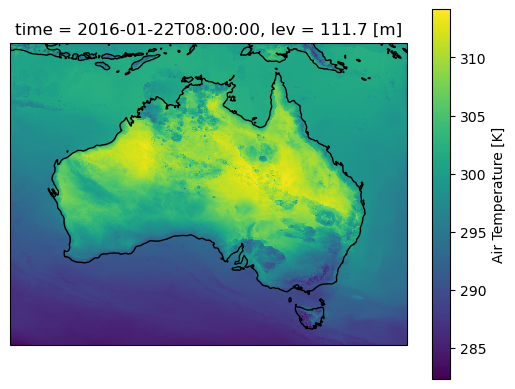

In [42]:
#First for the original air temperature data
ax=plt.axes(projection=ccrs.PlateCarree())
aus2200_ta.sel(time="2016-01-22 08:00").plot()
ax.coastlines()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 10.43 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


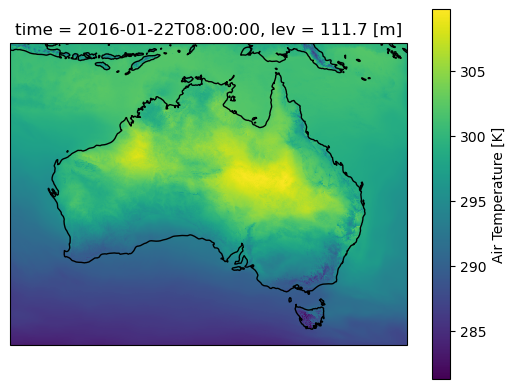

In [43]:
#And for the rolling daily mean
ax=plt.axes(projection=ccrs.PlateCarree())
aus2200_ta_daily_mean.sel(time="2016-01-22 08:00").plot()
ax.coastlines()

## Perturbations

Now calculate the temperature perturbations relative to the daily mean. Perturbations will re-introduce and highlight small-scale factors like convective cold pools and sea breezes along the coast, as well as allowing us to quantify the diurnal cycle.

In [44]:
aus2200_ta_daily_pert = aus2200_ta - aus2200_ta_daily_mean

## Plotting

As above, but for temperatue perturbations. Also plot for a single lat/lon location for the entire month

Note that the time series computation takes a lot longer, because dask needs to access many more files on disk (AUS2200 data is saved in 6-hourly files as discussed earlier)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


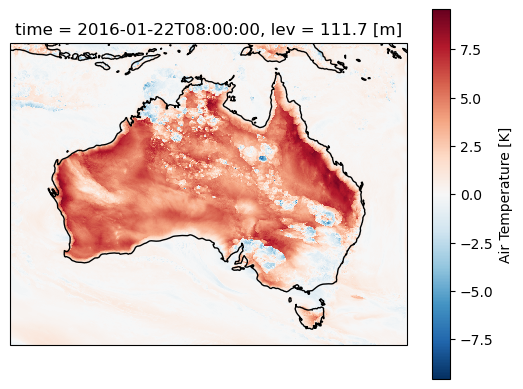

In [45]:
ax=plt.axes(projection=ccrs.PlateCarree())
aus2200_ta_daily_pert.sel(time="2016-01-22 08:00").plot()
ax.coastlines()

In [46]:
# This does not work: see https://github.com/dask/dask/issues/12198
aus2200_ta_daily_pert = aus2200_ta_daily_pert.sel(lat=-31.9275, lon=115.9764, method="nearest").plot()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-05-15 09:51:29,083 - distributed.worker - ERROR - Compute Failed
Key:       ('getitem-overlap-_trim-9debcf9e98eb529079aaf1b071f41466', 0, 0, 2, 0)
State:     executing
Task:  <Task ('getitem-overlap-_trim-9debcf9e98eb529079aaf1b071f41466', 0, 0, 2, 0) _execute_subgraph(...)>
Exception: "ValueError('Moving window (=24) must between 1 and 23, inclusive')"
Traceback: ''



ValueError: Moving window (=24) must between 1 and 23, inclusive

#### Contributors

* **Andrew Brown**

    ARC Centre of Excellence for 21st Century Weather, University of Melbourne
    

* **Samuel Green**

    ARC Centre of Excellence for 21st Century Weather & Climate Change Research Centre, UNSW Sydney

* **Charles Turner**

    ACCESS-NRI, Australian National University, Canberra
    
If you have any enquries, suggested improvements or bug reports related to this recipe, please [open an issue](https://github.com/ACCESS-Community-Hub/atmosphere-cookbook/issues/new?template=Blank+issue) or [start a discussion](https://github.com/ACCESS-Community-Hub/atmosphere-cookbook/discussions/new/choose) in this repository.